(np.float64(-0.5), np.float64(8063.5), np.float64(3023.5), np.float64(-0.5))

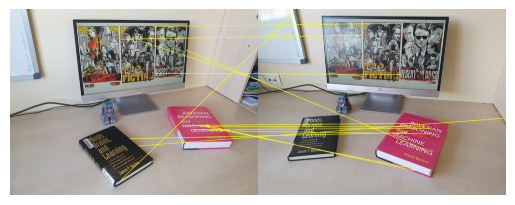

In [2]:





import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread("sample_images/office1.jpg")
img2 = cv2.imread("sample_images/office2.jpg")

# Perform SIFT
sift = cv2.SIFT_create() #Internally creates SIFT PIPELINE
kp1, des1 = sift.detectAndCompute(img1, None) 
kp2, des2 = sift.detectAndCompute(img2, None)

#kp1 and kp2 are arrays that contains details of all the keypoints
# des1 and des2 are descriptors that contains numerical representation of those keypoints 128 length

# Use Brute force Matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)  #Uses eucledian distance to find similarity and crosscheck to make sure it
#returns only the closest distance from both points

matches = bf.match(des1, des2) #Compares descriptors fromm one image to descriptors of another image
matches = sorted(matches, key=lambda x: x.distance)[:15] # displaying top 15 matches only

# Create a blank canvas 'vis' for visualization
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
vis = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8) #side by side two blank images combined 
vis[:h1, :w1] = img1           # add img1 to first half
#if h1=400 then we take from 0-400 all rows
# if w1=400 we takes from 0- 400 columns 
#This completes image 1

vis[:h2, w1:w1 + w2] = img2    # add img2 to second half
#image 2 starts from the end where image 1 ended which is x=400(the width of image 1
#height will be from 0-400 image 2 and width lets say 300
#width from w1(400) to width 700 i.e 400+300


# Draw match lines
for m in matches: #for each best 15 matches
    pt1 = tuple(map(int, kp1[m.queryIdx].pt))  # m.queryIdx tells which kypoint in image 1 is involved in each of the 15 matches
    #.pt gives its coordinates ex:[125.5,210.7] (location)
    
    pt2 = tuple(map(int, kp2[m.trainIdx].pt)) 
    pt2 = (int(pt2[0] + w1), int(pt2[1]))  

    #pt2 contains location fromn second image ex:(50,100)
    # To make sure it is corretly present in image2 when combined and since image 2 starts from 400-700
    # we do pt[0] i.e 50 +w1 i.e 400 so it becomes 450
    
    color = (0, 255, 255)  #Matching line bright yellow
    cv2.line(vis, pt1, pt2, color, 7)  # thickness=2
    cv2.circle(vis, pt1, 5, (0, 255, 0), -1)  # keypoints in image1 5 is the radius and -1 is keypoints filled
    cv2.circle(vis, pt2, 5, (0, 0, 255), -1)  # keypoints in image2

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")